# 判断为什么P=0 
 包括 冰盖、湖泊、河流、海岸线等；
 之后删除这些点

 	1.	从最开始的 precipitation_annual.nc 提取 30 年平均后 P=0 的点
	2.	先把所有 P=0 点可视化
	3.	判断这些点是否在 湖泊 / 河流 / 冰盖
	4.	再判断剩余点里哪些在 海岸线 50 km 内
	5.	计算剩下的陆地 P=0 点占比
	6.	可视化这些剩下的 P=0 点

## 第一块：读取 nc，并提取 30 年平均后的 P=0 点

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.ops import unary_union

# -----------------------------
# 1. 读取 nc
# -----------------------------
nc_path = Path("./../data/precipitation_annual.nc")

ds = xr.open_dataset(nc_path)
da = ds["precipitation"]

# 只取 1991–2020
da_30yr = da.sel(time=slice(1991, 2020))
da_mean = da_30yr.mean(dim="time", skipna=True)

lats = da_mean["latitude"].values
lons = da_mean["longitude"].values
mean_values = da_mean.values

lon2d, lat2d = np.meshgrid(lons, lats)

# 全部有效格点
grid_df = pd.DataFrame({
    "lon": lon2d.ravel(),
    "lat": lat2d.ravel(),
    "precipitation": mean_values.ravel()
})
grid_df = grid_df[np.isfinite(grid_df["precipitation"])].copy()

# P = 0 点
p0_df = grid_df[grid_df["precipitation"] == 0].copy()

print("Total valid cells:", len(grid_df))
print("Total P=0 cells:", len(p0_df))

Total valid cells: 3446983
Total P=0 cells: 2000396


## 第二块：先把所有 P=0 点画出来

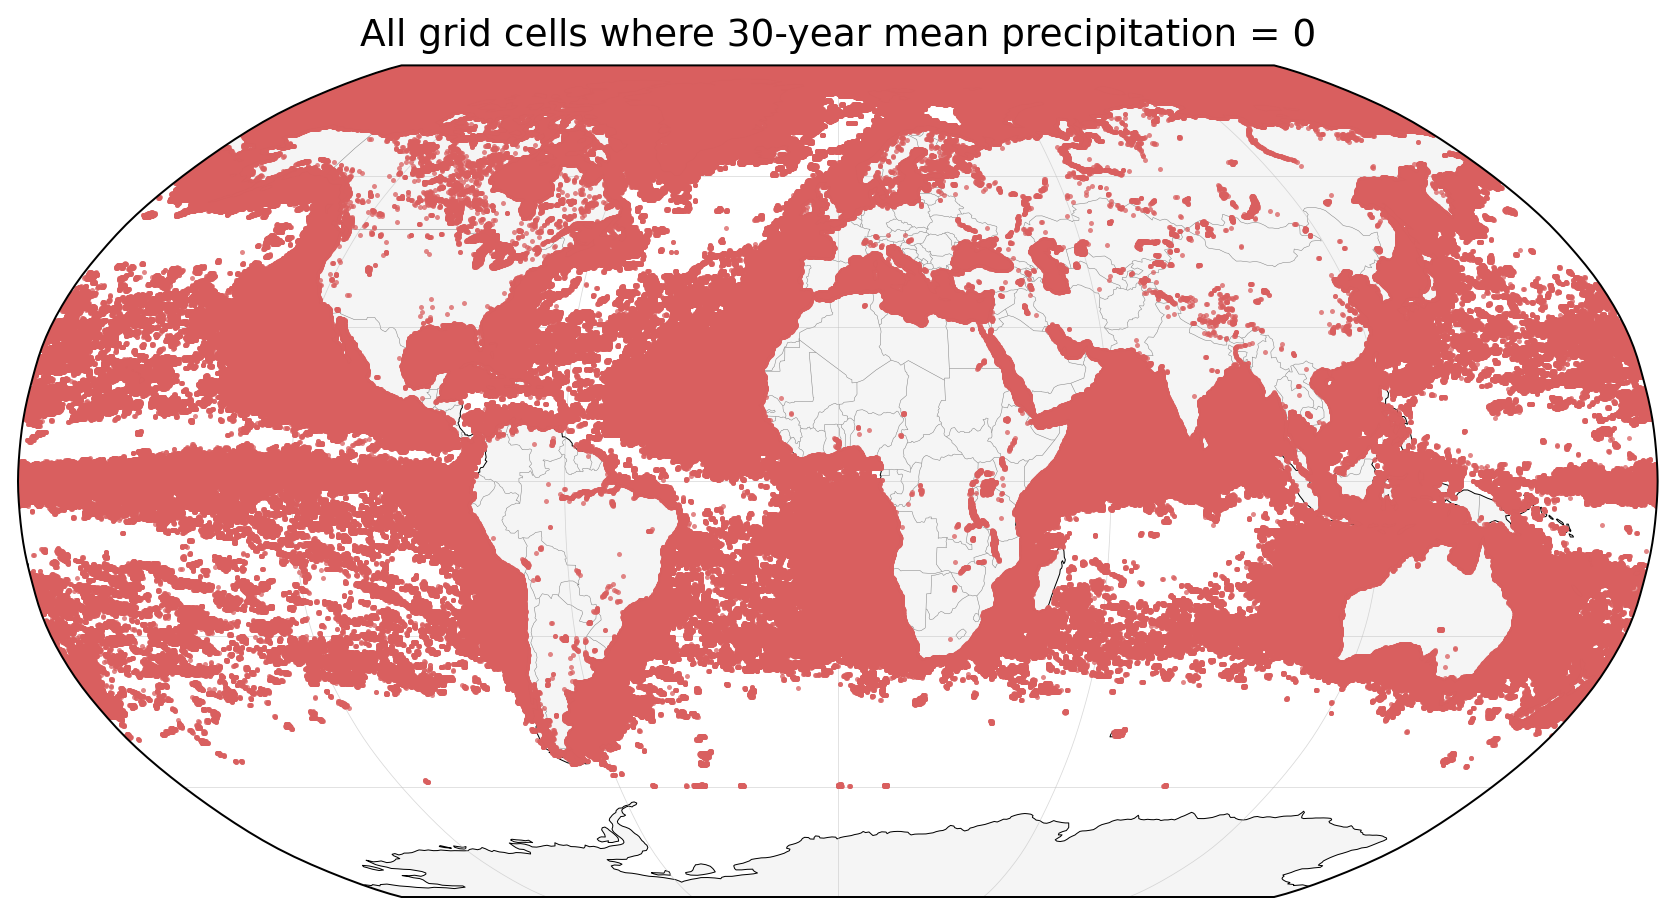

In [69]:
def plot_p0_points_global(df_zero, title, point_color="#D95F5F", point_size=4, alpha=0.75):
    fig = plt.figure(figsize=(12, 6), dpi=180)
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()

    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
    ax.coastlines(linewidth=0.4, color="black", zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=1)

    ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.3,
        color="0.75",
        alpha=0.6,
        linestyle="-",
        zorder=1
    )

    ax.scatter(
        df_zero["lon"],
        df_zero["lat"],
        s=point_size,
        color=point_color,
        alpha=alpha,
        linewidth=0,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.set_title(title, fontsize=15, pad=8)
    plt.show()

plot_p0_points_global(p0_df, "All grid cells where 30-year mean precipitation = 0")

## 第三块：读取 land / lakes / rivers / glacier shapefile

注意：河流是 centerlines，后面会先做缓冲区。

In [31]:
# -----------------------------
# 2. 读取 shp：global + North America supplement
# -----------------------------
water_dir = Path("./../data/water_area")

# Global
land_path = water_dir / "ne_10m_land" / "ne_10m_land.shp"
lakes_path = water_dir / "ne_10m_lakes" / "ne_10m_lakes.shp"
glacier_path = water_dir / "ne_10m_glaciated_areas" / "ne_10m_glaciated_areas.shp"
rivers_path = water_dir / "ne_10m_rivers_lake_centerlines" / "ne_10m_rivers_lake_centerlines.shp"

# North America supplement
lakes_na_path = water_dir / "ne_10m_lakes_north_america" / "ne_10m_lakes_north_america.shp"
rivers_na_path = water_dir / "ne_10m_rivers_north_america" / "ne_10m_rivers_north_america.shp"

# 读取 global
land = gpd.read_file(land_path)
lakes = gpd.read_file(lakes_path)
glaciers = gpd.read_file(glacier_path)
rivers = gpd.read_file(rivers_path)

# 读取 NA supplement
lakes_na = gpd.read_file(lakes_na_path)
rivers_na = gpd.read_file(rivers_na_path)

# 统一 CRS
if land.crs is not None:
    land = land.to_crs(epsg=4326)

if lakes.crs is not None:
    lakes = lakes.to_crs(epsg=4326)

if glaciers.crs is not None:
    glaciers = glaciers.to_crs(epsg=4326)

if rivers.crs is not None:
    rivers = rivers.to_crs(epsg=4326)

if lakes_na.crs is not None:
    lakes_na = lakes_na.to_crs(epsg=4326)

if rivers_na.crs is not None:
    rivers_na = rivers_na.to_crs(epsg=4326)

# 合并到原变量名 lakes / rivers 中
lakes = pd.concat([lakes, lakes_na], ignore_index=True)
lakes = gpd.GeoDataFrame(lakes, geometry="geometry", crs="EPSG:4326")

rivers = pd.concat([rivers, rivers_na], ignore_index=True)
rivers = gpd.GeoDataFrame(rivers, geometry="geometry", crs="EPSG:4326")

print("Land polygons:", len(land))
print("Lake polygons (global + NA):", len(lakes))
print("Glacier polygons:", len(glaciers))
print("River geometries (global + NA):", len(rivers))

Land polygons: 11
Lake polygons (global + NA): 2517
Glacier polygons: 1886
River geometries (global + NA): 6370


In [5]:
# # -----------------------------
# # 2. 读取 shp
# # -----------------------------
# water_dir = Path("./../data/water_area")

# land_path = water_dir / "ne_10m_land" / "ne_10m_land.shp"
# lakes_path = water_dir / "ne_10m_lakes" / "ne_10m_lakes.shp"
# glacier_path = water_dir / "ne_10m_glaciated_areas" / "ne_10m_glaciated_areas.shp"
# rivers_path = water_dir / "ne_10m_rivers_lake_centerlines" / "ne_10m_rivers_lake_centerlines.shp"

# land = gpd.read_file(land_path)
# lakes = gpd.read_file(lakes_path)
# glaciers = gpd.read_file(glacier_path)
# rivers = gpd.read_file(rivers_path)

# # 统一 CRS
# for gdf_name, gdf in [("land", land), ("lakes", lakes), ("glaciers", glaciers), ("rivers", rivers)]:
#     if gdf.crs is not None:
#         locals()[gdf_name] = gdf.to_crs(epsg=4326)

# print("Land polygons:", len(land))
# print("Lake polygons:", len(lakes))
# print("Glacier polygons:", len(glaciers))
# print("River geometries:", len(rivers))

Land polygons: 11
Lake polygons: 1355
Glacier polygons: 1886
River geometries: 1473


## 第四块：把 P=0 点转成 GeoDataFrame，并判断在湖泊 / 河流 / 冰盖 / 陆地 / 海洋
这里河流先做一个 5 km 缓冲区。你也可以改成 2 km 或 10 km。

In [32]:
# -----------------------------
# 3. P=0 点转 GeoDataFrame
# -----------------------------
p0_gdf = gpd.GeoDataFrame(
    p0_df.copy(),
    geometry=gpd.points_from_xy(p0_df["lon"], p0_df["lat"]),
    crs="EPSG:4326"
)

def mark_points_in_polygons(points_gdf, polygons_gdf, predicate="intersects"):
    joined = gpd.sjoin(
        points_gdf[["geometry"]],
        polygons_gdf,
        how="left",
        predicate=predicate
    )
    matched_idx = joined.loc[joined["index_right"].notna()].index.unique()
    return points_gdf.index.isin(matched_idx)

# 陆地 / 海洋
p0_gdf["on_land"] = mark_points_in_polygons(p0_gdf, land, predicate="intersects")
p0_gdf["in_ocean"] = ~p0_gdf["on_land"]

# 湖泊
p0_gdf["in_lake"] = mark_points_in_polygons(p0_gdf, lakes, predicate="intersects")

# 冰盖
p0_gdf["in_glacier"] = mark_points_in_polygons(p0_gdf, glaciers, predicate="intersects")

### 4.1 河流缓冲区

In [51]:
# -----------------------------
# 4. 河流需要缓冲区（使用已经合并后的 rivers）
# -----------------------------
river_buffer_km = 5

# 投影到米单位 CRS 做缓冲
rivers_m = rivers.to_crs(epsg=3857)
river_buffer = rivers_m.buffer(river_buffer_km * 1000)

river_buffer_gdf = gpd.GeoDataFrame(
    geometry=river_buffer,
    crs="EPSG:3857"
).to_crs(epsg=4326)

p0_gdf["in_river"] = mark_points_in_polygons(
    p0_gdf,
    river_buffer_gdf,
    predicate="intersects"
)

print(f"River buffer distance: {river_buffer_km} km")

River buffer distance: 5 km


## 第五块：判断海岸线 50 km 内的点

这里只对“还没被湖泊 / 河流 / 冰盖解释”的陆地 P=0 点再看海岸线。

In [57]:
# -----------------------------
# 5. 先提取陆地上且不在 lake/river/glacier 的 P=0 点
# -----------------------------
p0_land_core = p0_gdf[
    (p0_gdf["on_land"]) &
    (~p0_gdf["in_lake"]) &
    (~p0_gdf["in_river"]) &
    (~p0_gdf["in_glacier"])
].copy()

print("Land P=0 after removing lake/river/glacier:", len(p0_land_core))

Land P=0 after removing lake/river/glacier: 17701


In [58]:

# -----------------------------
# 6. 海岸线距离
# -----------------------------
land_union = unary_union(land.geometry)
coastline = land_union.boundary

coastline_gdf = gpd.GeoDataFrame(
    {"name": ["coastline"]},
    geometry=[coastline],
    crs="EPSG:4326"
)

# 转到米单位 CRS 计算距离
p0_land_core_m = p0_land_core.to_crs(epsg=3857)
coastline_m = coastline_gdf.to_crs(epsg=3857)

coast_geom = coastline_m.geometry.iloc[0]
p0_land_core_m["dist_to_coast_km"] = p0_land_core_m.geometry.distance(coast_geom) / 1000

coastal_threshold_km = 50
p0_land_core_m["near_coast"] = p0_land_core_m["dist_to_coast_km"] <= coastal_threshold_km

In [59]:
# 最后剩下的、未解释的陆地 P=0 点
remaining_p0_land = p0_land_core_m[
    ~p0_land_core_m["near_coast"]
].copy()

print("Remaining unexplained land P=0 cells:", len(remaining_p0_land))

Remaining unexplained land P=0 cells: 6074


In [60]:
remaining_p0_land_ll = remaining_p0_land.to_crs(epsg=4326)

In [73]:
# -----------------------------
# 2. 把所有有效格点转成 GeoDataFrame
# -----------------------------
grid_gdf = gpd.GeoDataFrame(
    grid_df.copy(),
    geometry=gpd.points_from_xy(grid_df["lon"], grid_df["lat"]),
    crs="EPSG:4326"
)

p0_gdf = gpd.GeoDataFrame(
    p0_df.copy(),
    geometry=gpd.points_from_xy(p0_df["lon"], p0_df["lat"]),
    crs="EPSG:4326"
)

# -----------------------------
# 3. 读取 Natural Earth 陆地边界
# -----------------------------
land = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip"
)

land = land.to_crs("EPSG:4326")
land_union = unary_union(land.geometry)

# -----------------------------
# 4. 判断哪些格点在陆地上
# -----------------------------
grid_gdf["on_land"] = grid_gdf.geometry.intersects(land_union)
p0_gdf["on_land"] = p0_gdf.geometry.intersects(land_union)

# -----------------------------
# 5. 统计数量
# -----------------------------
total_valid_cells = len(grid_gdf)
total_land_cells = grid_gdf["on_land"].sum()

total_p0_cells = len(p0_gdf)
total_land_p0_cells = p0_gdf["on_land"].sum()

print("Total valid cells:", total_valid_cells)
print("Total land cells:", total_land_cells)
print("Total P=0 cells:", total_p0_cells)
print("Total land P=0 cells:", total_land_p0_cells)

print("Land cells / valid cells (%):", total_land_cells / total_valid_cells * 100)
print("Land P=0 cells / all P=0 cells (%):", total_land_p0_cells / total_p0_cells * 100)
print("Land P=0 cells / all land cells (%):", total_land_p0_cells / total_land_cells * 100)

KeyboardInterrupt: 

In [61]:
total_valid_cells = len(grid_df)
total_p0_cells = len(p0_gdf)
total_land_p0_cells = p0_gdf["on_land"].sum()

n_lake = p0_gdf["in_lake"].sum()
n_river = p0_gdf["in_river"].sum()
n_glacier = p0_gdf["in_glacier"].sum()
n_coastal = p0_land_core_m["near_coast"].sum()
n_remaining_land = len(remaining_p0_land)

summary = pd.DataFrame({
    "metric": [
        "total_valid_cells",
        "total_p0_cells",
        "total_land_p0_cells",
        "p0_in_lake",
        "p0_in_river",
        "p0_in_glacier",
        f"p0_land_near_coast_le_{coastal_threshold_km}km",
        "remaining_land_p0_cells",
    ],
    "count": [
        total_valid_cells,
        total_p0_cells,
        total_land_p0_cells,
        n_lake,
        n_river,
        n_glacier,
        n_coastal,
        n_remaining_land,
    ]
})

summary["pct_of_all_valid_cells"] = summary["count"] / total_valid_cells * 100
summary["pct_of_land_p0_cells"] = np.nan

mask = summary["metric"].isin([
    "p0_in_lake",
    "p0_in_river",
    "p0_in_glacier",
    f"p0_land_near_coast_le_{coastal_threshold_km}km",
    "remaining_land_p0_cells",
])

summary.loc[mask, "pct_of_land_p0_cells"] = (
    summary.loc[mask, "count"] / total_land_p0_cells * 100
)

print(summary.round(3))

                       metric    count  pct_of_all_valid_cells  \
0           total_valid_cells  3446983                 100.000   
1              total_p0_cells  2000396                  58.033   
2         total_land_p0_cells    94978                   2.755   
3                  p0_in_lake    12320                   0.357   
4                 p0_in_river     2481                   0.072   
5               p0_in_glacier    64206                   1.863   
6  p0_land_near_coast_le_50km    11627                   0.337   
7     remaining_land_p0_cells     6074                   0.176   

   pct_of_land_p0_cells  
0                   NaN  
1                   NaN  
2                   NaN  
3                12.971  
4                 2.612  
5                67.601  
6                12.242  
7                 6.395  


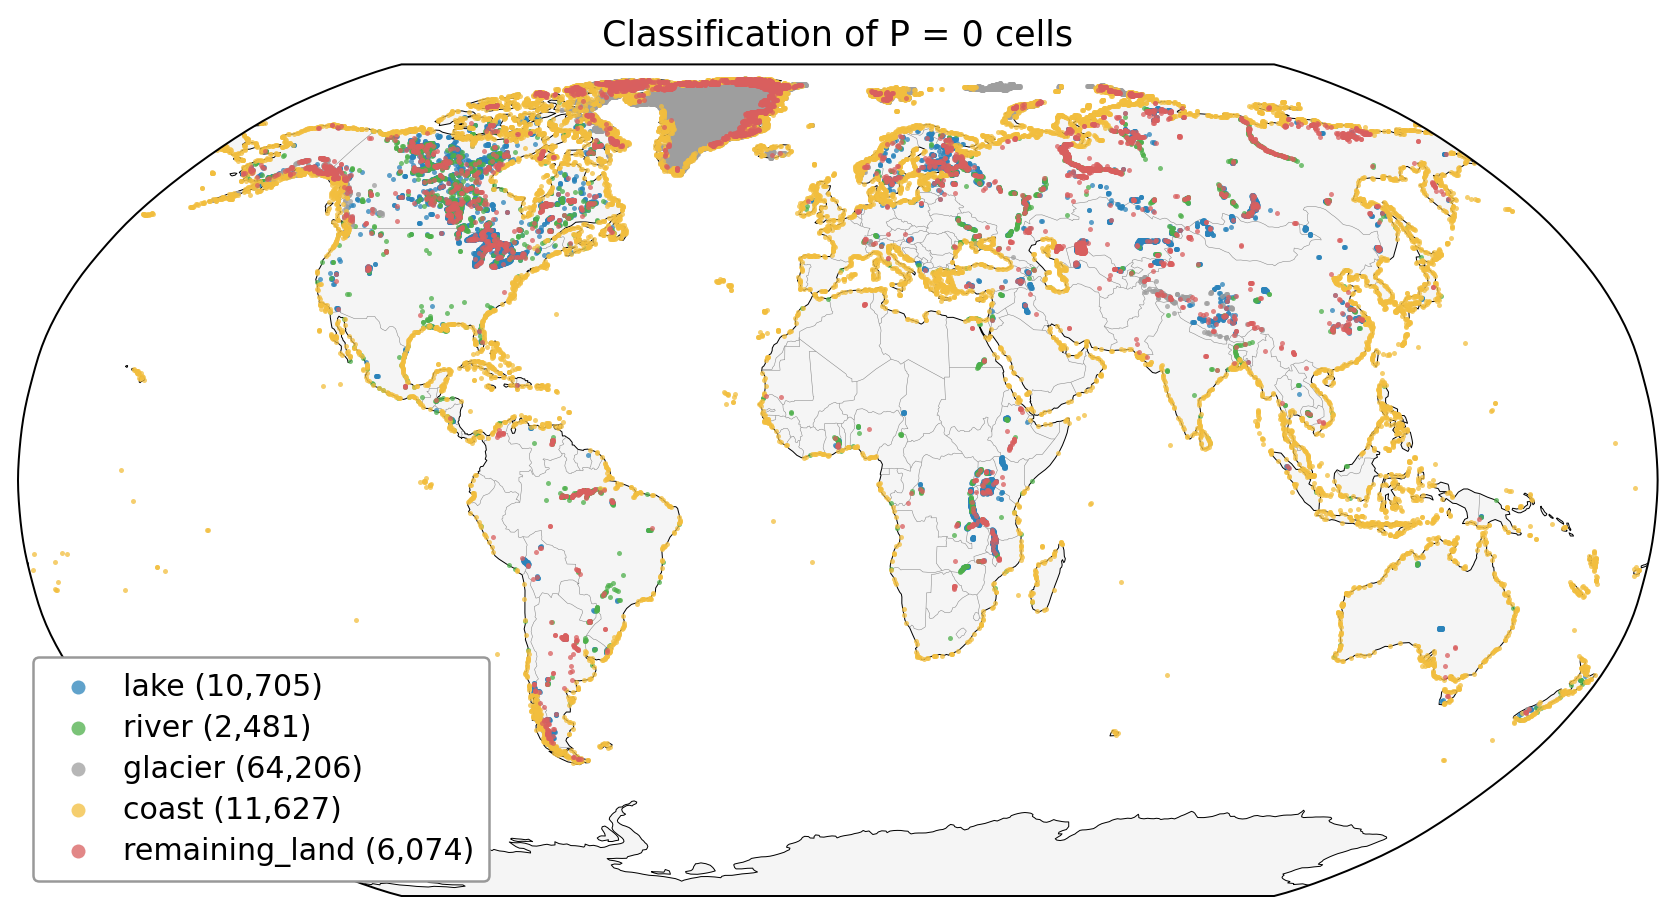

In [68]:
classified = p0_gdf.copy()
classified["category"] = "other"

classified.loc[classified["in_lake"], "category"] = "lake"
classified.loc[classified["in_river"], "category"] = "river"
classified.loc[classified["in_glacier"], "category"] = "glacier"

# 对 land core 再加 near coast 标签
coastal_idx = p0_land_core_m[p0_land_core_m["near_coast"]].index
classified.loc[classified.index.isin(coastal_idx), "category"] = "coast"

remaining_idx = remaining_p0_land.index
classified.loc[classified.index.isin(remaining_idx), "category"] = "remaining_land"

color_map = {
    "lake": "#2B83BA",
    "river": "#4DAF4A",
    "glacier": "#9E9E9E",
    "coast": "#F2BE3E",
    "remaining_land": "#D95F5F",
    "other": "#BFBFBF"
}

fig = plt.figure(figsize=(12, 6), dpi=180)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
ax.coastlines(linewidth=0.4, color="black", zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=1)

for cat in ["lake", "river", "glacier", "coast", "remaining_land"]:
    sub = classified[classified["category"] == cat]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub["lon"],
        sub["lat"],
        s=4,
        color=color_map[cat],
        alpha=0.75,
        linewidth=0,
        transform=ccrs.PlateCarree(),
        zorder=2,
        label=f"{cat} ({len(sub):,})"
    )

ax.legend(
    loc="lower left",
    fontsize=12,
    markerscale=2.8,
    frameon=True,
    framealpha=1,
    facecolor="white",
    edgecolor="0.6",
    borderpad=0.5,
    labelspacing=0.4,
    handletextpad=0.5
)

ax.set_title("Classification of P = 0 cells", fontsize=14, pad=8)
plt.show()

In [4]:
# 如果有 time 维，可以先做平均
if "time" in da.dims:
    da2d = da.mean(dim="time")
else:
    da2d = da

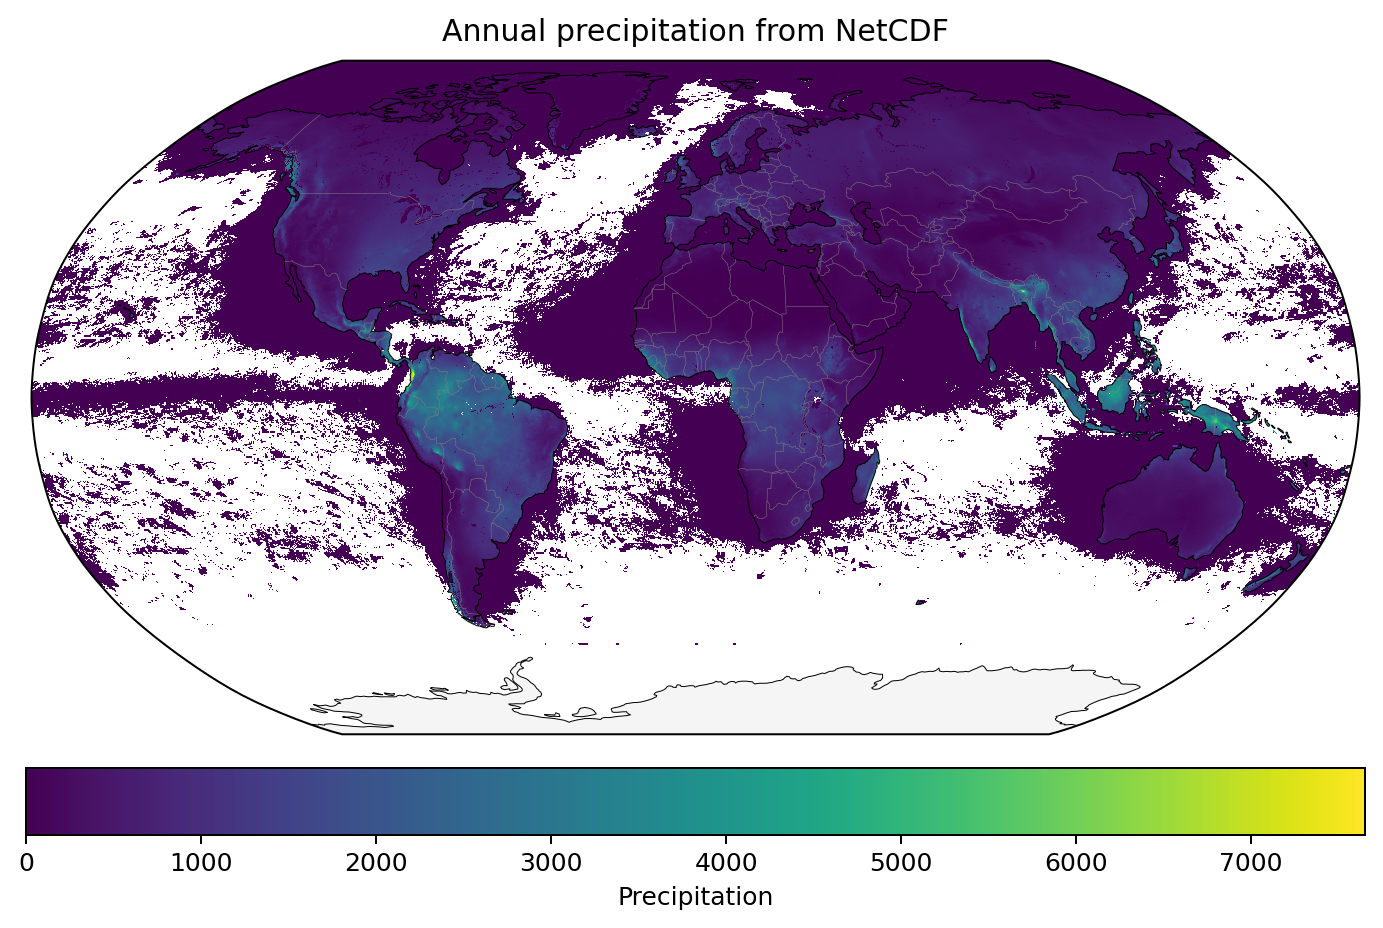

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 6), dpi=180)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
ax.coastlines(linewidth=0.4, color="black", zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=2)

mesh = ax.pcolormesh(
    lons,
    lats,
    da2d.values,
    transform=ccrs.PlateCarree(),
    shading="auto",
    zorder=1
)

cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.04, shrink=0.8)
cbar.set_label("Precipitation", fontsize=10)

ax.set_title("Annual precipitation from NetCDF", fontsize=12, pad=8)
plt.show()